<a href="https://colab.research.google.com/github/shadmanr1/Milestone_1/blob/main/Week_10_Notebook_Shadman_Raakin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

#Dataset: Movie Box office (2000-2024)
General overview of the dataset is that it provides a detailed analysis of global box office performance from 2000 to 2024. It includes information on movies released during this period, covering key metrics such as release dates, genres, production budgets, worldwide gross, and more. The dataset aims to assist researchers, data scientists, and movie enthusiasts in exploring trends in the film industry, analyzing profitability, and understanding audience preferences over the years. https://www.kaggle.com/datasets/aditya126/movies-box-office-dataset-2000-2024?select=enhanced_box_office_data%282000-2024%29u.csv

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving enhanced_box_office_data(2000-2024)u.csv to enhanced_box_office_data(2000-2024)u.csv


In [ ]:
df = pd.read_csv("enhanced_box_office_data(2000-2024)u.csv")
# Convert rating from "6.126/10" to 6.126
df["Rating_num"] = pd.to_numeric(df["Rating"].astype(str).str.extract(r"([0-9.]+)")[0],errors="coerce")
# Log-transform highly skewed variables
df["Log_Vote_Count"] = np.log1p(df["Vote_Count"])
df["Log_Worldwide"] = np.log1p(df["$Worldwide"])

Selecting clustering features

In [ ]:
cluster_features = ["Year","Rating_num","Log_Vote_Count","Log_Worldwide","Domestic %"]
X = df[cluster_features].copy()

Handling missing values for K means:

In [ ]:
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_imputed)

Testing out the Elbow method

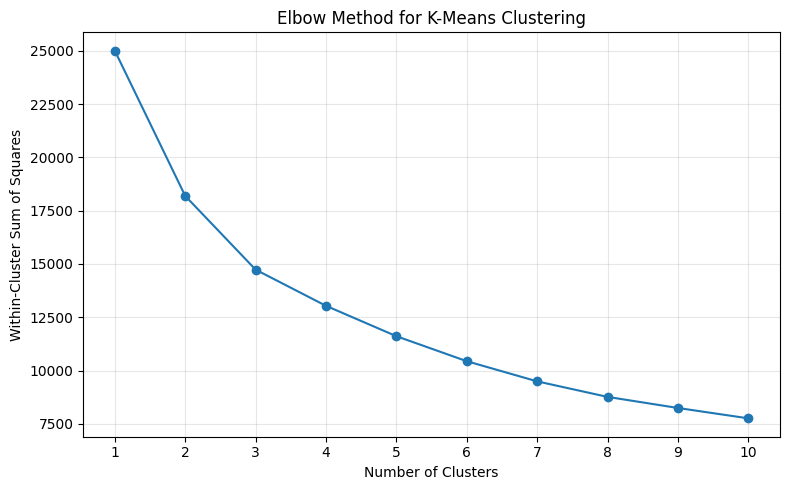

In [ ]:
k_values = range(1, 11)
inertia_values = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=42)

    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(k_values,inertia_values,marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Within-Cluster Sum of Squares")
plt.title("Elbow Method for K-Means Clustering")
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Made a table of the results of the chart

| Number of clusters |  Inertia |
| -----------------: | -------: |
|                  2 | 18,190.7 |
|                  3 | 14,733.2 |
|                  4 | 13,037.8 |
|                  5 | 11,613.1 |
|                  6 | 10,440.6 |
|                  7 |  9,495.3 |
|                  8 |  8,766.8 |
|                  9 |  8,246.9 |
|                 10 |  7,761.2 |


The largest practical improvement occurs when moving from two to three clusters. After approximately three or four clusters, the reduction in inertia becomes increasingly gradual. Therefore, the elbow plot would likely support either two or three clusters.

The elbow is not extremely sharp, which means there is no single unquestionably correct number of clusters

Silhouette score

In [ ]:
silhouette_results = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(
        X_scaled,
        labels,
        metric="euclidean")
    silhouette_results.append({
        "Clusters": k,
        "Silhouette_Score": score})
silhouette_df = pd.DataFrame(silhouette_results)
print(silhouette_df)

   Clusters  Silhouette_Score
0         2          0.282854
1         3          0.250805
2         4          0.245440
3         5          0.236721
4         6          0.235262
5         7          0.227640
6         8          0.227951
7         9          0.220774
8        10          0.217147


Plot based on the table:

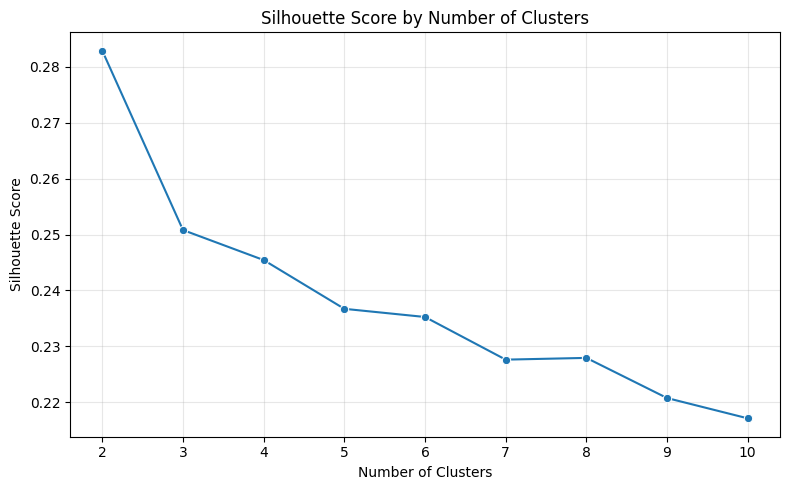

In [ ]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=silhouette_df,
    x="Clusters",
    y="Silhouette_Score",
    marker="o")

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The highest silhouette score occurs at k=2. Therefore, based strictly on silhouette score, two clusters provide the strongest separation.
However, a score of 0.283 is modest. It indicates that the movies form overlapping groups rather than extremely distinct natural clusters.

Next, we'll fit the selected two cluster model

In [ ]:
final_kmeans = KMeans(
    n_clusters=2,
    n_init=20,
    random_state=42)

df["Cluster"] = final_kmeans.fit_predict(X_scaled)

Cluster summary

In [ ]:
cluster_summary = df.groupby("Cluster").agg(
    Number_of_Movies=("Cluster", "size"),
    Average_Year=("Year", "mean"),
    Average_Rating=("Rating_num", "mean"),
    Median_Vote_Count=("Vote_Count", "median"),
    Median_Worldwide_Revenue=("$Worldwide", "median"),
    Average_Domestic_Percent=("Domestic %", "mean")).round(2)

print(cluster_summary)

         Number_of_Movies  Average_Year  Average_Rating  Median_Vote_Count  \
Cluster                                                                      
0                    3106       2010.42            6.56             2208.0   
1                    1894       2014.59            6.43              129.0   

         Median_Worldwide_Revenue  Average_Domestic_Percent  
Cluster                                                      
0                      83023521.0                     53.77  
1                      25960326.5                      6.17  


In [ ]:
cluster_table = pd.DataFrame({
    "Number of Movies": [3106, 1894],
    "Average Year": [2010.42, 2014.59],
    "Average Rating": [6.56, 6.43],
    "Median Vote Count": [2208, 129],
    "Median Worldwide Revenue": [83023521.0, 25960326.5],
    "Average Domestic Percent": [53.77, 6.17]
}, index=["Cluster 0", "Cluster 1"])

cluster_table

,Number of Movies,Average Year,Average Rating,Median Vote Count,Median Worldwide Revenue,Average Domestic Percent
Cluster 0,3106,2010.42,6.56,2208,83023521.0,53.77
Cluster 1,1894,2014.59,6.43,129,25960326.5,6.17


Based on the table summary:
Cluster 0: established, domestically successful movies

These movies have:
Higher median worldwide revenue
Much higher vote counts
Slightly higher ratings
A substantial share of revenue from the domestic market
A somewhat earlier average release year

This cluster appears to contain more widely seen and established theatrical releases.

Cluster 1: internationally concentrated, lower-engagement movies

These movies have:

Lower median revenue
Far fewer votes
Slightly lower average ratings
Very little domestic revenue
A more recent average release year

PCA Scaling:

In [ ]:
kmeans_three = KMeans(
    n_clusters=3,
    n_init=20,
    random_state=42)

df["Cluster_3"] = kmeans_three.fit_predict(X_scaled)

three_cluster_summary = df.groupby("Cluster_3").agg(
    Number_of_Movies=("Cluster_3", "size"),
    Average_Year=("Year", "mean"),
    Average_Rating=("Rating_num", "mean"),
    Median_Vote_Count=("Vote_Count", "median"),
    Median_Worldwide_Revenue=("$Worldwide", "median"),
    Average_Domestic_Percent=("Domestic %", "mean")
).round(2)

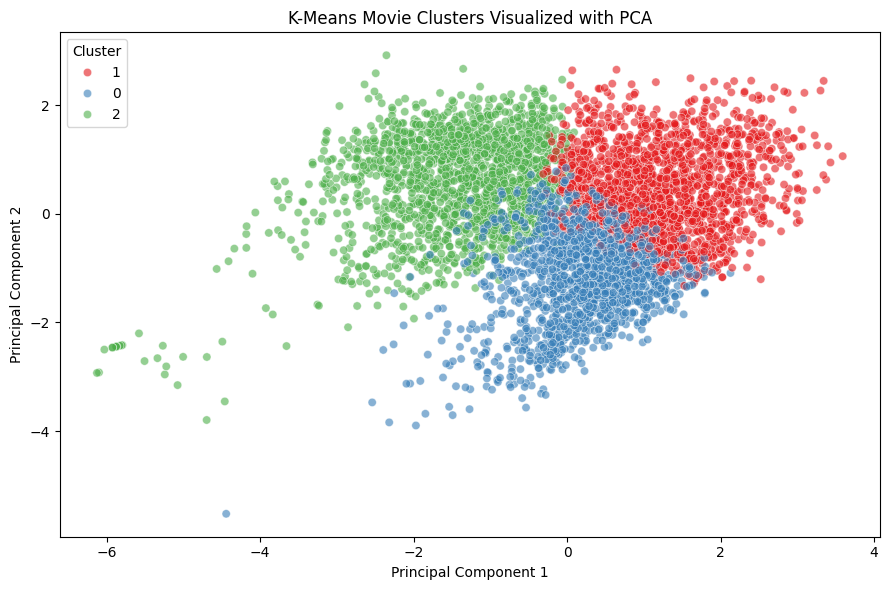

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": df["Cluster_3"].astype(str)})

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    alpha=0.6)

plt.title("K-Means Movie Clusters Visualized with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


Based strictly on the silhouette score, k=2 is the strongest choice. It separates established, domestically successful movies from lower-engagement movies with little domestic revenue.
Moderate-revenue, domestically concentrated movies
High-revenue, highly rated and widely viewed movies
Lower-revenue, internationally concentrated movies

The modest silhouette scores indicate that these segments overlap considerably. Therefore, the clusters should be understood as broad movie profiles, not rigid or naturally isolated categories.